# Job Market Demand - Data Exploration

This notebook explores the core O*NET Content Model files:
- **Abilities.xlsx**: Worker abilities linked to occupations
- **Education.xlsx**: Education requirements and frequencies
- **Essential Skills.xlsx**: Essential skills and occupation linkages

Goal: Understand the structure, quality, and content of these O*NET datasets before building matching and analysis models.

## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Datasets

In [ ]:
# Define dataset paths
datasets_dir = Path('datasets/onet')

abilities_path = datasets_dir / 'Abilities.xlsx'
education_path = datasets_dir / 'Education.xlsx'
essential_skills_path = datasets_dir / 'Essential Skills.xlsx'
software_skills_path = datasets_dir / 'Software Skills.xlsx'

# Load datasets
print("Loading datasets...")
df_abilities = pd.read_excel(abilities_path)
df_education = pd.read_excel(education_path)
df_essential_skills = pd.read_excel(essential_skills_path)
df_software_skills = pd.read_excel(software_skills_path)

print("✓ All datasets loaded successfully!")
print(f"- Abilities.xlsx: {df_abilities.shape[0]} rows, {df_abilities.shape[1]} columns")
print(f"- Education.xlsx: {df_education.shape[0]} rows, {df_education.shape[1]} columns")
print(f"- Essential Skills.xlsx: {df_essential_skills.shape[0]} rows, {df_essential_skills.shape[1]} columns")
print(f"- Software Skills.xlsx: {df_software_skills.shape[0]} rows, {df_software_skills.shape[1]} columns")

Loading datasets...
✓ All datasets loaded successfully!
- Abilities.xlsx: 92976 rows, 15 columns
- Education.xlsx: 11100 rows, 15 columns
- Essential Skills.xlsx: 17880 rows, 15 columns


In [ ]:
print("\n=== EXCEL DATA INSPECTION ===")
for df, label, path in [
    (df_abilities, 'Abilities', abilities_path),
    (df_education, 'Education', education_path),
    (df_essential_skills, 'Essential Skills', essential_skills_path),
    (df_software_skills, 'Software Skills', software_skills_path),
]:
    print(f"\n{path.name}")
    print(f"  rows: {len(df)}")
    print(f"  columns: {len(df.columns)}")
    print(f"  sample columns: {list(df.columns[:20])}")


=== EXCEL DATA INSPECTION ===

Abilities.xlsx
  rows: 92976
  columns: 15
  sample columns: ['O*NET-SOC Code', 'Title', 'Element ID', 'Element Name', 'Scale ID', 'Scale Name', 'Data Value', 'N', 'Standard Error', 'Lower CI Bound', 'Upper CI Bound', 'Recommend Suppress', 'Not Relevant', 'Date', 'Domain Source']

Education.xlsx
  rows: 11100
  columns: 15
  sample columns: ['O*NET-SOC Code', 'Title', 'Element ID', 'Element Name', 'Scale ID', 'Scale Name', 'Category', 'Data Value', 'N', 'Standard Error', 'Lower CI Bound', 'Upper CI Bound', 'Recommend Suppress', 'Date', 'Domain Source']

Essential Skills.xlsx
  rows: 17880
  columns: 15
  sample columns: ['O*NET-SOC Code', 'Title', 'Element ID', 'Element Name', 'Scale ID', 'Scale Name', 'Data Value', 'N', 'Standard Error', 'Lower CI Bound', 'Upper CI Bound', 'Recommend Suppress', 'Not Relevant', 'Date', 'Domain Source']


In [8]:
print("Excel data exploration setup complete.")

Excel data exploration setup complete.


## 3. Explore Abilities.xlsx Dataset

### Schema and Data Types

In [9]:
print("=" * 60)
print("ABILITIES DATASET ANALYSIS")
print("=" * 60)
print("\nData Types:")
print(df_abilities.dtypes)
print("\n" + "=" * 60)
print("First 5 Rows:")
print(df_abilities.head())
print("\n" + "=" * 60)
print("Column Names:")
for i, col in enumerate(df_abilities.columns, 1):
    print(f"{i}. {col}")

ABILITIES DATASET ANALYSIS

Data Types:
O*NET-SOC Code            str
Title                     str
Element ID                str
Element Name              str
Scale ID                  str
Scale Name                str
Data Value            float64
N                       int64
Standard Error        float64
Lower CI Bound        float64
Upper CI Bound        float64
Recommend Suppress        str
Not Relevant              str
Date                      str
Domain Source             str
dtype: object

First 5 Rows:
  O*NET-SOC Code             Title Element ID           Element Name Scale ID  \
0     11-1011.00  Chief Executives  1.A.1.a.1     Oral Comprehension       IM   
1     11-1011.00  Chief Executives  1.A.1.a.1     Oral Comprehension       LV   
2     11-1011.00  Chief Executives  1.A.1.a.2  Written Comprehension       IM   
3     11-1011.00  Chief Executives  1.A.1.a.2  Written Comprehension       LV   
4     11-1011.00  Chief Executives  1.A.1.a.3        Oral Expression       I

In [10]:
print("\nMissing Values:")
missing = df_abilities.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values!")
else:
    print(missing[missing > 0])

print("\nBasic Statistics:")
print(df_abilities.describe(include='all'))


Missing Values:
Not Relevant    46488
dtype: int64

Basic Statistics:
       O*NET-SOC Code             Title Element ID        Element Name  \
count           92976             92976      92976               92976   
unique            894               894         52                  52   
top        11-1011.00  Chief Executives  1.A.1.a.1  Oral Comprehension   
freq              104               104       1788                1788   
mean              NaN               NaN        NaN                 NaN   
std               NaN               NaN        NaN                 NaN   
min               NaN               NaN        NaN                 NaN   
25%               NaN               NaN        NaN                 NaN   
50%               NaN               NaN        NaN                 NaN   
75%               NaN               NaN        NaN                 NaN   
max               NaN               NaN        NaN                 NaN   

       Scale ID  Scale Name    Data Valu

## 4. Explore Education.xlsx Dataset

In [11]:
print("=" * 60)
print("EDUCATION DATASET ANALYSIS")
print("=" * 60)
print("\nData Types:")
print(df_education.dtypes)
print("\n" + "=" * 60)
print("First 5 Rows:")
print(df_education.head())
print("\n" + "=" * 60)
print("Column Names:")
for i, col in enumerate(df_education.columns, 1):
    print(f"{i}. {col}")

print("\nMissing Values:")
missing = df_education.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values!")
else:
    print(missing[missing > 0])

print("\nBasic Statistics:")
print(df_education.describe(include='all'))

EDUCATION DATASET ANALYSIS

Data Types:
O*NET-SOC Code            str
Title                     str
Element ID                str
Element Name              str
Scale ID                  str
Scale Name                str
Category              float64
Data Value            float64
N                       int64
Standard Error        float64
Lower CI Bound        float64
Upper CI Bound        float64
Recommend Suppress        str
Date                      str
Domain Source             str
dtype: object

First 5 Rows:
  O*NET-SOC Code             Title Element ID                 Element Name  \
0     11-1011.00  Chief Executives      2.D.1  Required Level of Education   
1     11-1011.00  Chief Executives      2.D.1  Required Level of Education   
2     11-1011.00  Chief Executives      2.D.1  Required Level of Education   
3     11-1011.00  Chief Executives      2.D.1  Required Level of Education   
4     11-1011.00  Chief Executives      2.D.1  Required Level of Education   

  Scale ID  

## 5. Explore Essential Skills.xlsx Dataset

In [12]:
print("=" * 60)
print("ESSENTIAL SKILLS DATASET ANALYSIS")
print("=" * 60)
print("\nData Types:")
print(df_essential_skills.dtypes)
print("\n" + "=" * 60)
print("First 5 Rows:")
print(df_essential_skills.head())
print("\n" + "=" * 60)
print("Column Names:")
for i, col in enumerate(df_essential_skills.columns, 1):
    print(f"{i}. {col}")

print("\nMissing Values:")
missing = df_essential_skills.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values!")
else:
    print(missing[missing > 0])

print("\nBasic Statistics:")
print(df_essential_skills.describe(include='all'))

ESSENTIAL SKILLS DATASET ANALYSIS

Data Types:
O*NET-SOC Code            str
Title                     str
Element ID                str
Element Name              str
Scale ID                  str
Scale Name                str
Data Value            float64
N                       int64
Standard Error        float64
Lower CI Bound        float64
Upper CI Bound        float64
Recommend Suppress        str
Not Relevant              str
Date                      str
Domain Source             str
dtype: object

First 5 Rows:
  O*NET-SOC Code             Title Element ID           Element Name Scale ID  \
0     11-1011.00  Chief Executives    2.A.1.a  Reading Comprehension       IM   
1     11-1011.00  Chief Executives    2.A.1.a  Reading Comprehension       LV   
2     11-1011.00  Chief Executives    2.A.1.b       Active Listening       IM   
3     11-1011.00  Chief Executives    2.A.1.b       Active Listening       LV   
4     11-1011.00  Chief Executives    2.A.1.c                Writing 

## 6. Explore Software Skills.xlsx Dataset

### Schema and Data Types

In [ ]:
print("=" * 60)
print("SOFTWARE SKILLS DATASET ANALYSIS")
print("=" * 60)
print("\nData Types:")
print(df_software_skills.dtypes)
print("\n" + "=" * 60)
print("First 5 Rows:")
print(df_software_skills.head())
print("\n" + "=" * 60)
print("Column Names:")
for i, col in enumerate(df_software_skills.columns, 1):
    print(f"{i}. {col}")

print("\nMissing Values:")
missing = df_software_skills.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values!")
else:
    print(missing[missing > 0])

print("\nBasic Statistics:")
print(df_software_skills.describe(include='all'))

## 7. Summary & Key Findings

In [ ]:
print("\n" + "=" * 60)
print("SUMMARY OF DATASETS")
print("=" * 60)

summary = pd.DataFrame({
    'Dataset': ['Abilities', 'Education', 'Essential Skills', 'Software Skills'],
    'Rows': [len(df_abilities), len(df_education), len(df_essential_skills), len(df_software_skills)],
    'Columns': [len(df_abilities.columns), len(df_education.columns), len(df_essential_skills.columns), len(df_software_skills.columns)],
    'Missing Values': [df_abilities.isnull().sum().sum(), df_education.isnull().sum().sum(), df_essential_skills.isnull().sum().sum(), df_software_skills.isnull().sum().sum()],
    'Data Types': [
        f"Numeric: {(df_abilities.dtypes == 'int64').sum() + (df_abilities.dtypes == 'float64').sum()}, Object: {(df_abilities.dtypes == 'object').sum()}",
        f"Numeric: {(df_education.dtypes == 'int64').sum() + (df_education.dtypes == 'float64').sum()}, Object: {(df_education.dtypes == 'object').sum()}",
        f"Numeric: {(df_essential_skills.dtypes == 'int64').sum() + (df_essential_skills.dtypes == 'float64').sum()}, Object: {(df_essential_skills.dtypes == 'object').sum()}",
        f"Numeric: {(df_software_skills.dtypes == 'int64').sum() + (df_software_skills.dtypes == 'float64').sum()}, Object: {(df_software_skills.dtypes == 'object').sum()}"
    ]
})

print("\n")
print(summary.to_string(index=False))
print("\n" + "=" * 60)
print("Next Steps:")
print("1. Review the schema of each dataset above")
print("2. Check for salary data and skill information")
print("3. Plan data cleaning strategy")
print("4. Design feature engineering approach")
print("=" * 60)


SUMMARY OF DATASETS


         Dataset  Rows  Columns  Missing Values            Data Types
       Abilities 92976       15           46488 Numeric: 5, Object: 0
       Education 11100       15           20958 Numeric: 6, Object: 0
Essential Skills 17880       15            8940 Numeric: 5, Object: 0

Next Steps:
1. Review the schema of each dataset above
2. Check for salary data and skill information
3. Plan data cleaning strategy
4. Design feature engineering approach


## 8. Importance Relationships Across O*NET Datasets

This section plots how O*NET descriptors relate to their average importance or score in each dataset. The graphs are intended to help identify the most important abilities, education levels, and essential skills by occupation.


Dataset: Abilities
Descriptor column: Element Name
Importance column: Data Value


/var/folders/y4/lh8fczc90wl0bvv1dm11w49m0000gn/T/ipykernel_41174/3243411138.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


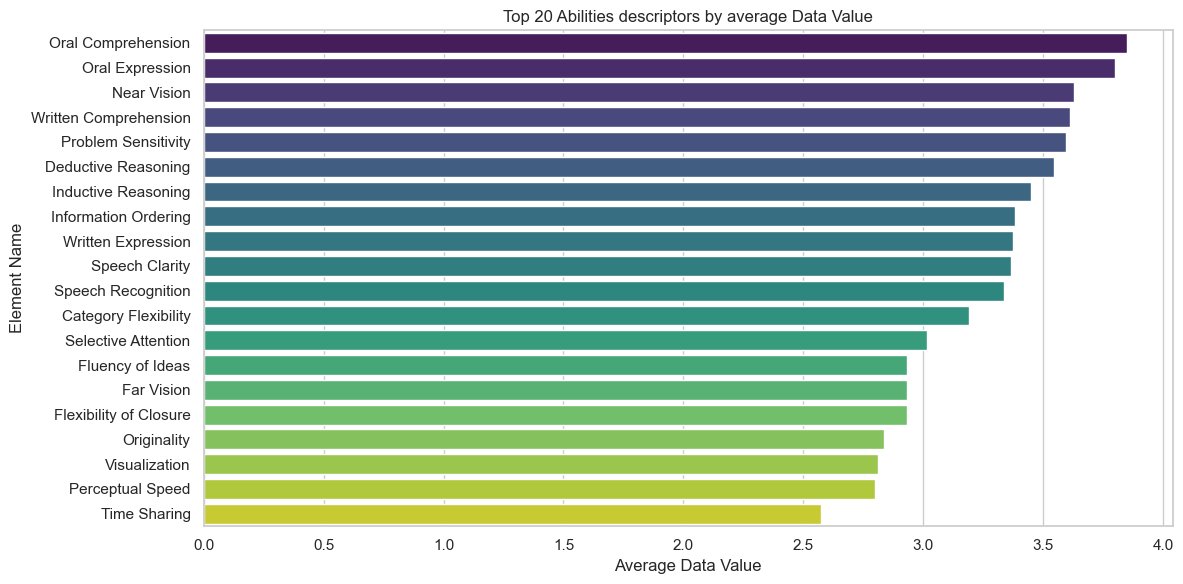


Dataset: Education
Descriptor column: Element Name
Importance column: Data Value


/var/folders/y4/lh8fczc90wl0bvv1dm11w49m0000gn/T/ipykernel_41174/3243411138.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


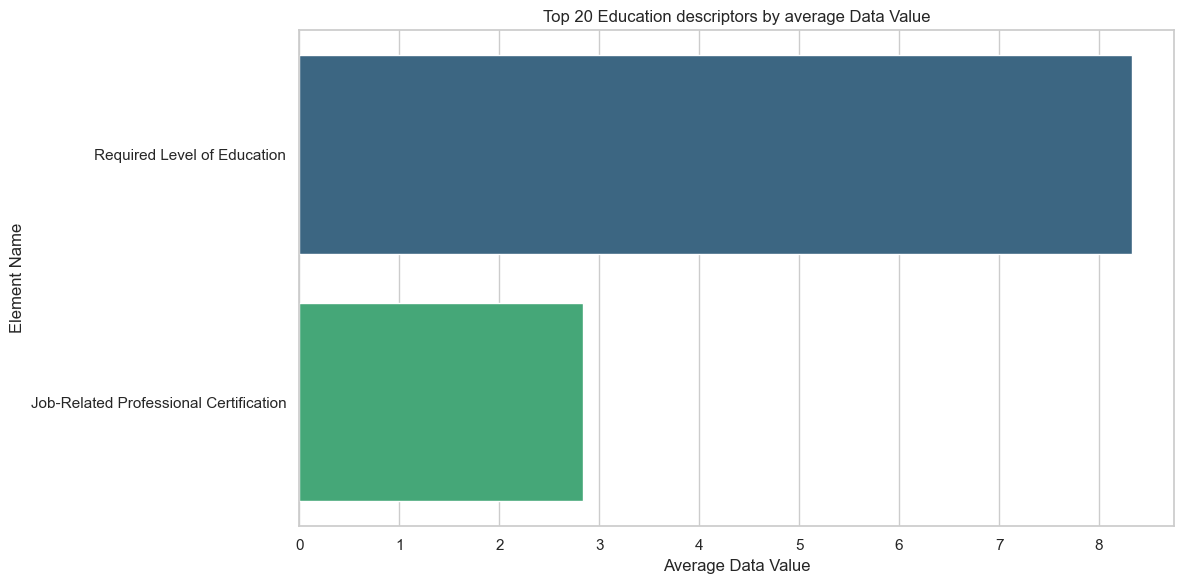


Dataset: Essential Skills
Descriptor column: Element Name
Importance column: Data Value


/var/folders/y4/lh8fczc90wl0bvv1dm11w49m0000gn/T/ipykernel_41174/3243411138.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


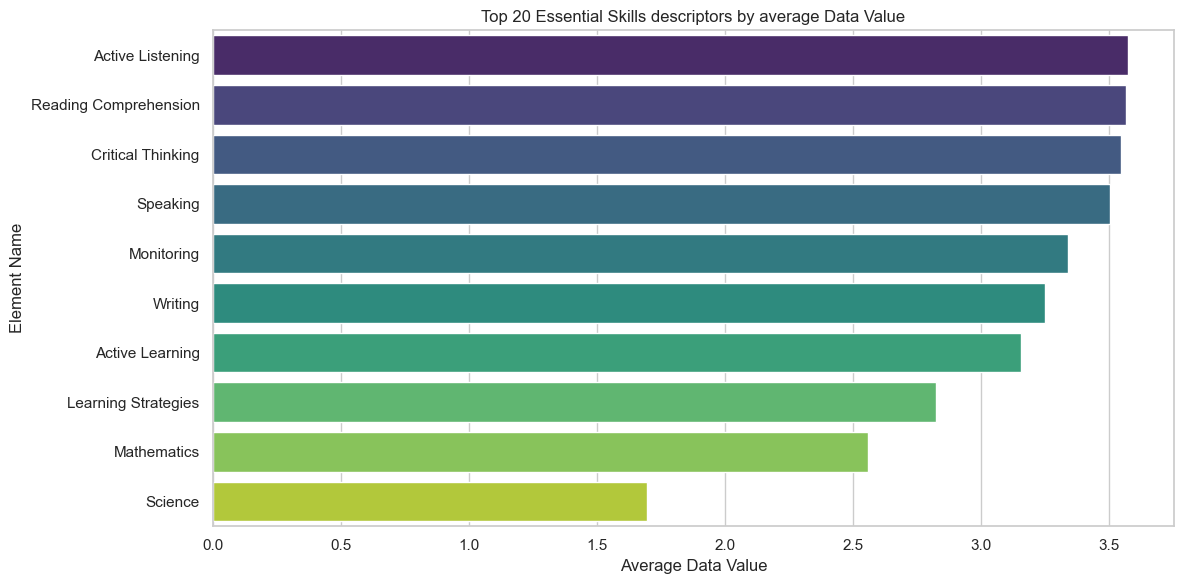

NameError: name 'df_software_skills' is not defined

In [18]:
# Helper functions for plotting O*NET importance relationships

import seaborn as sns

sns.set(style='whitegrid')


def find_descriptor_column(df):
    label_columns = [
        'Element Name', 'Descriptor Name', 'Scale Name', 'Category Name',
        'Ability Name', 'Knowledge Name', 'Skill Name', 'Occupation Title',
        'Job Zone', 'Education Category', 'Element', 'Descriptor'
    ]
    for col in label_columns:
        if col in df.columns:
            return col
    # fallback to first non-numeric column
    for col in df.columns:
        if df[col].dtype == object:
            return col
    return df.columns[0]


def find_importance_column(df):
    importance_columns = [
        'Data Value', 'Mean', 'Level', 'Importance', 'Percent', 'Value',
        'Scale ID', 'Level ID', 'Rating'
    ]
    for col in importance_columns:
        if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
            return col
    # fallback to first numeric column
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            return col
    return None


def plot_importance(df, dataset_name):
    descriptor_col = find_descriptor_column(df)
    importance_col = find_importance_column(df)
    if importance_col is None:
        print(f"No numeric importance column detected in {dataset_name}.")
        return

    aggregated = df.groupby(descriptor_col)[importance_col].mean().reset_index()
    aggregated = aggregated.sort_values(by=importance_col, ascending=False).head(20)

    print(f"\nDataset: {dataset_name}")
    print(f"Descriptor column: {descriptor_col}")
    print(f"Importance column: {importance_col}")

    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=aggregated,
        x=importance_col,
        y=descriptor_col,
        palette='viridis'
    )
    plt.title(f'Top 20 {dataset_name} descriptors by average {importance_col}')
    plt.xlabel(f'Average {importance_col}')
    plt.ylabel(descriptor_col)
    plt.tight_layout()
    plt.show()


plot_importance(df_abilities, 'Abilities')
plot_importance(df_education, 'Education')
plot_importance(df_essential_skills, 'Essential Skills')
plot_importance(df_software_skills, 'Software Skills')

## 9. Exploring All Available O*NET Excel Files

If more `.xlsx` files are present under `datasets/onet/`, this section will scan and compare the most informative numeric metrics across all files.

Found additional dataset files:
 - Abilities%20to%20Work%20Activities.xlsx
 - Abilities%20to%20Work%20Context.xlsx
 - Abilities_Competencies.xlsx
 - Content Model Reference.xlsx
 - Education%20Categories.xlsx
 - Essential%20Skills%20to%20Work%20Activities.xlsx
 - Essential%20Skills%20to%20Work%20Context.xlsx
 - Essential%20Skills.xlsx
 - Essential_Skills_Competencies.xlsx
 - Interests%20Illustrative%20Occupations.xlsx
 - Job Titles.xlsx
 - Knowledge.xlsx
 - Knowledge_Competencies.xlsx
 - Occupation Data.xlsx
 - Occupation Level Metadata.xlsx
 - Occupation%20Data.xlsx
 - Occupation%20Level%20Metadata.xlsx
 - Related%20Occupations.xlsx
 - Software Skills.xlsx
 - Software%20Skills.xlsx
 - Software_Skills_Competencies.xlsx
 - Task Statements.xlsx
 - Training and Experience.xlsx
 - Training%20and%20Experience%20Categories.xlsx
 - Training%20and%20Experience.xlsx
 - Transferable Skills.xlsx
 - Transferable%20Skills%20to%20Work%20Activities.xlsx
 - Transferable%20Skills%20to%20Work%20Context.

/var/folders/y4/lh8fczc90wl0bvv1dm11w49m0000gn/T/ipykernel_41174/617386588.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


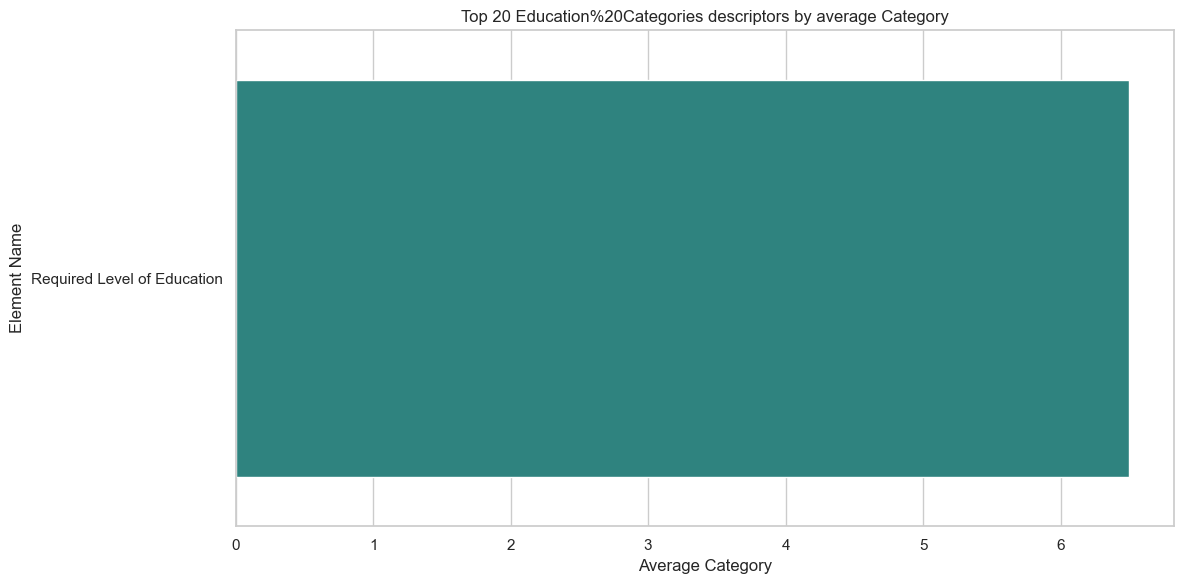

No numeric importance column detected in Essential%20Skills%20to%20Work%20Activities.
No numeric importance column detected in Essential%20Skills%20to%20Work%20Context.

Dataset: Essential%20Skills
Descriptor column: Element Name
Importance column: Data Value


/var/folders/y4/lh8fczc90wl0bvv1dm11w49m0000gn/T/ipykernel_41174/617386588.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


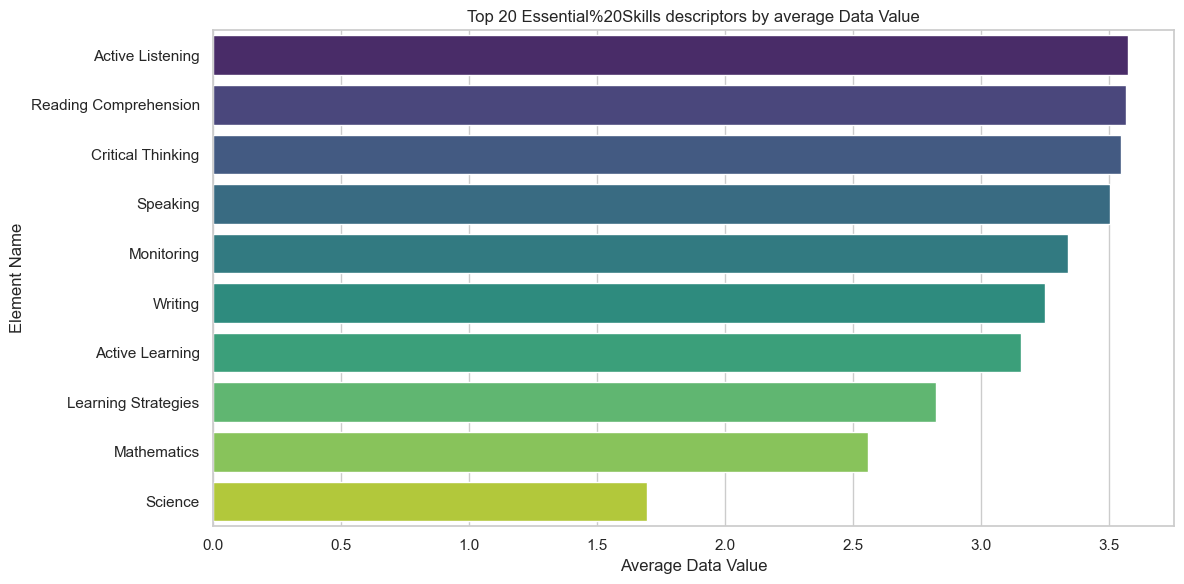

No numeric importance column detected in Essential_Skills_Competencies.
No numeric importance column detected in Interests%20Illustrative%20Occupations.
No numeric importance column detected in Job Titles.

Dataset: Knowledge
Descriptor column: Element Name
Importance column: Data Value


/var/folders/y4/lh8fczc90wl0bvv1dm11w49m0000gn/T/ipykernel_41174/617386588.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


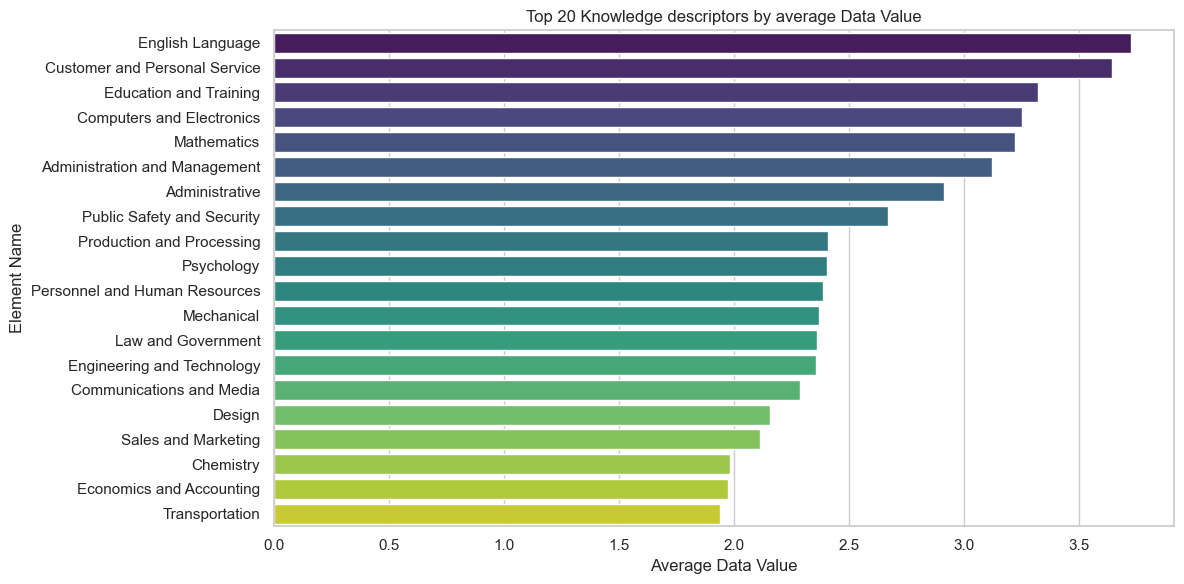

No numeric importance column detected in Knowledge_Competencies.
No numeric importance column detected in Occupation Data.

Dataset: Occupation Level Metadata
Descriptor column: O*NET-SOC Code
Importance column: Percent


/var/folders/y4/lh8fczc90wl0bvv1dm11w49m0000gn/T/ipykernel_41174/617386588.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


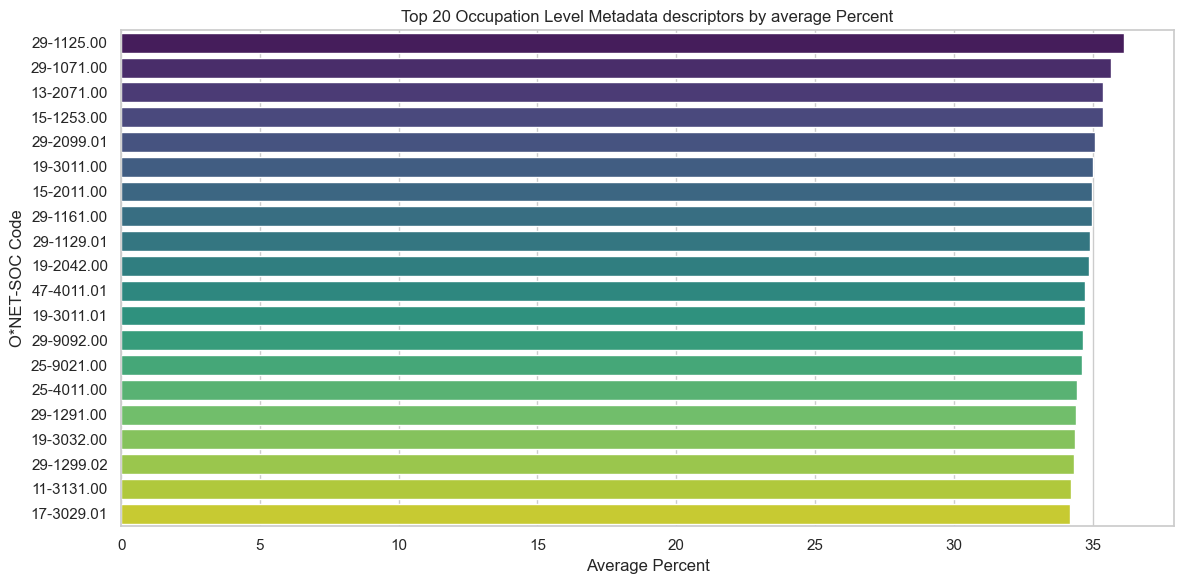

No numeric importance column detected in Occupation%20Data.

Dataset: Occupation%20Level%20Metadata
Descriptor column: O*NET-SOC Code
Importance column: Percent


/var/folders/y4/lh8fczc90wl0bvv1dm11w49m0000gn/T/ipykernel_41174/617386588.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


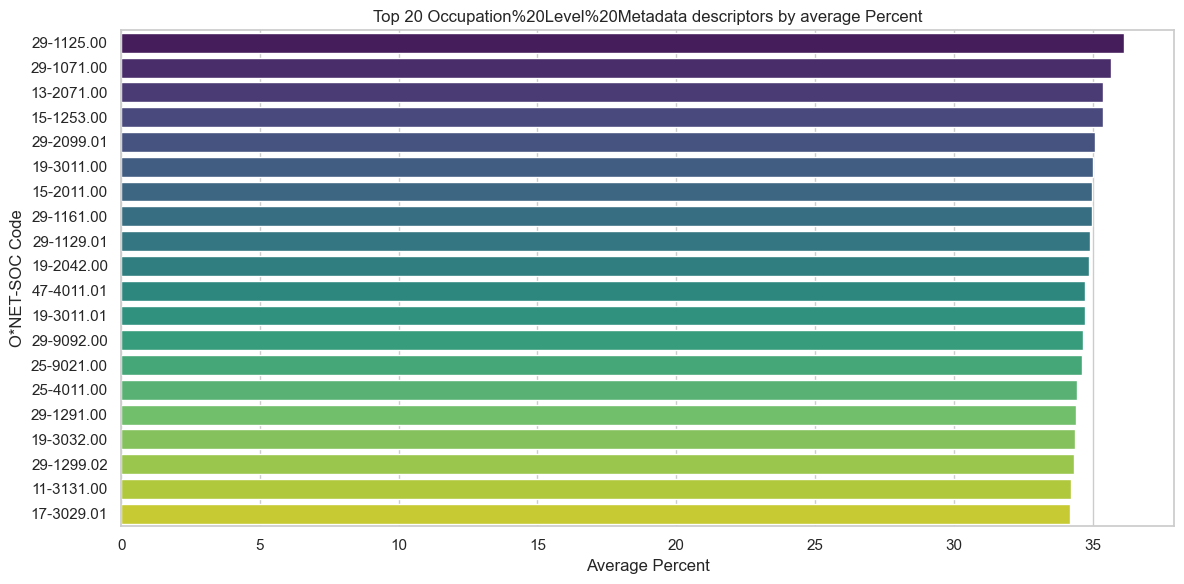


Dataset: Related%20Occupations
Descriptor column: O*NET-SOC Code
Importance column: Index


/var/folders/y4/lh8fczc90wl0bvv1dm11w49m0000gn/T/ipykernel_41174/617386588.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


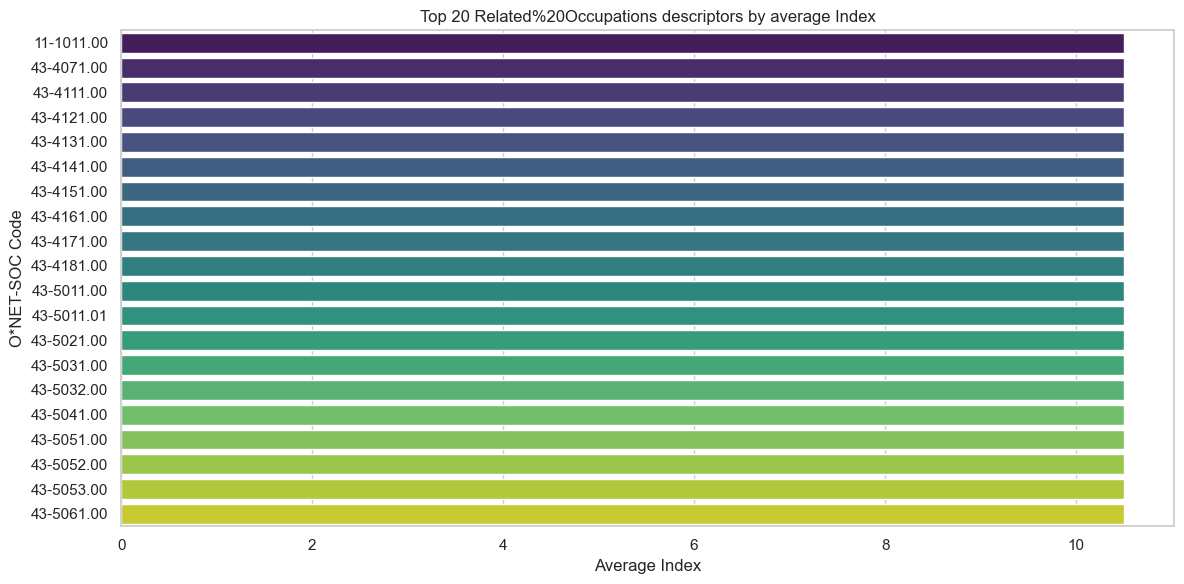

No numeric importance column detected in Software Skills.
No numeric importance column detected in Software%20Skills.
No numeric importance column detected in Software_Skills_Competencies.

Dataset: Task Statements
Descriptor column: O*NET-SOC Code
Importance column: Task ID


/var/folders/y4/lh8fczc90wl0bvv1dm11w49m0000gn/T/ipykernel_41174/617386588.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


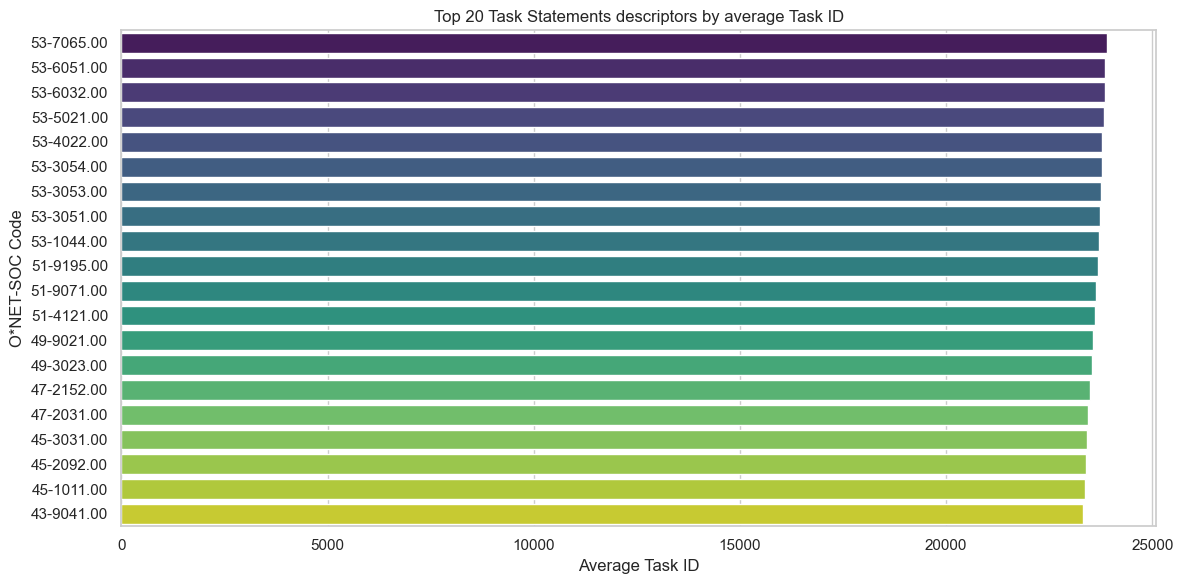


Dataset: Training and Experience
Descriptor column: Element Name
Importance column: Data Value


/var/folders/y4/lh8fczc90wl0bvv1dm11w49m0000gn/T/ipykernel_41174/617386588.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


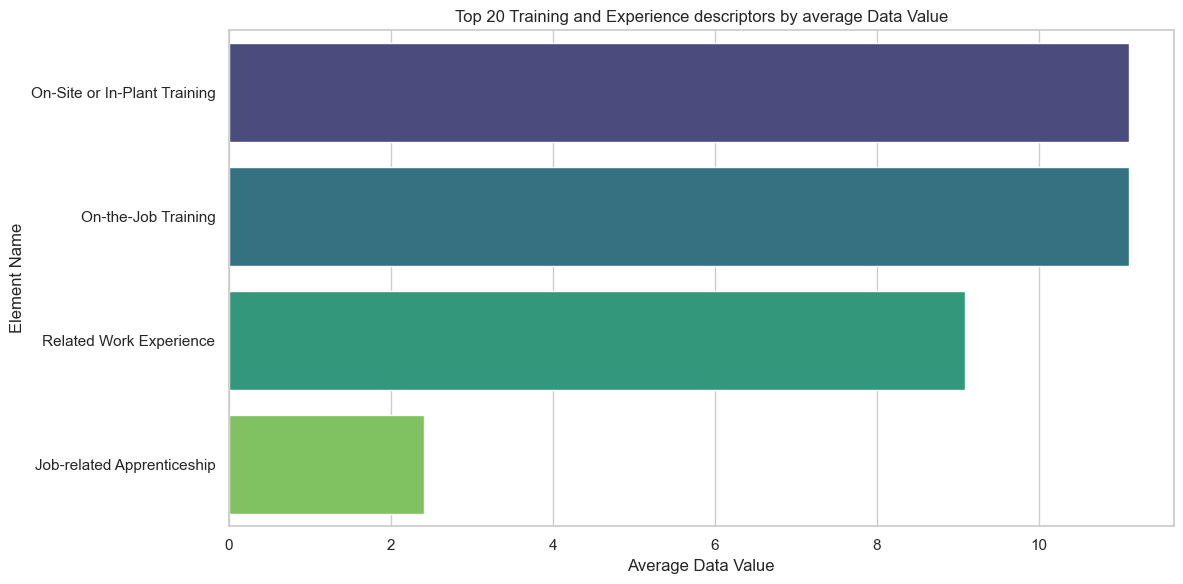


Dataset: Training%20and%20Experience%20Categories
Descriptor column: Element Name
Importance column: Category


/var/folders/y4/lh8fczc90wl0bvv1dm11w49m0000gn/T/ipykernel_41174/617386588.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


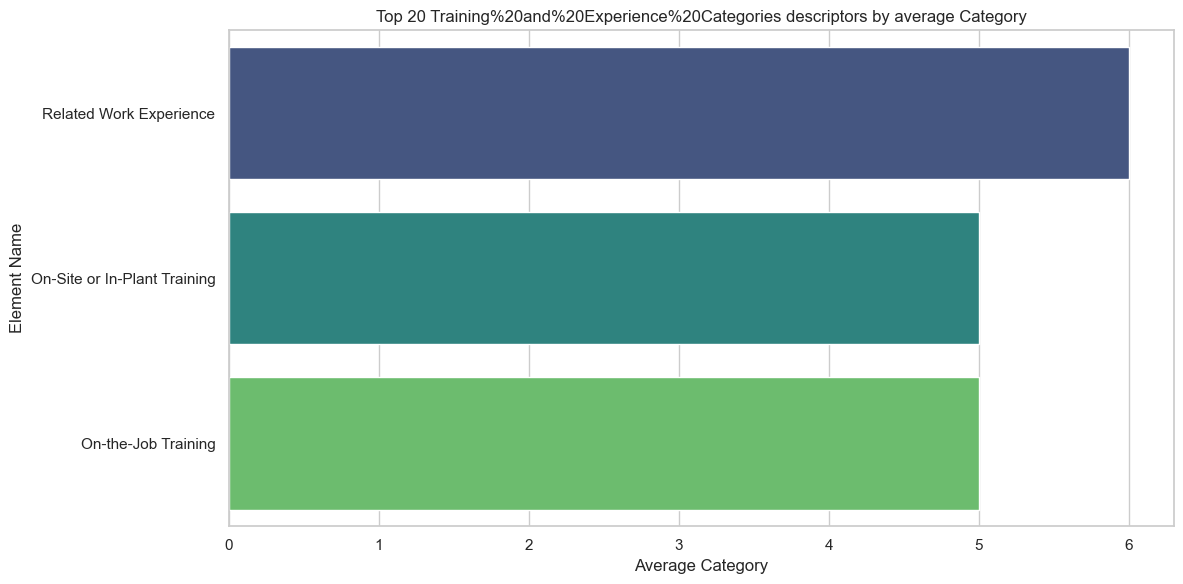


Dataset: Training%20and%20Experience
Descriptor column: Element Name
Importance column: Data Value


/var/folders/y4/lh8fczc90wl0bvv1dm11w49m0000gn/T/ipykernel_41174/617386588.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


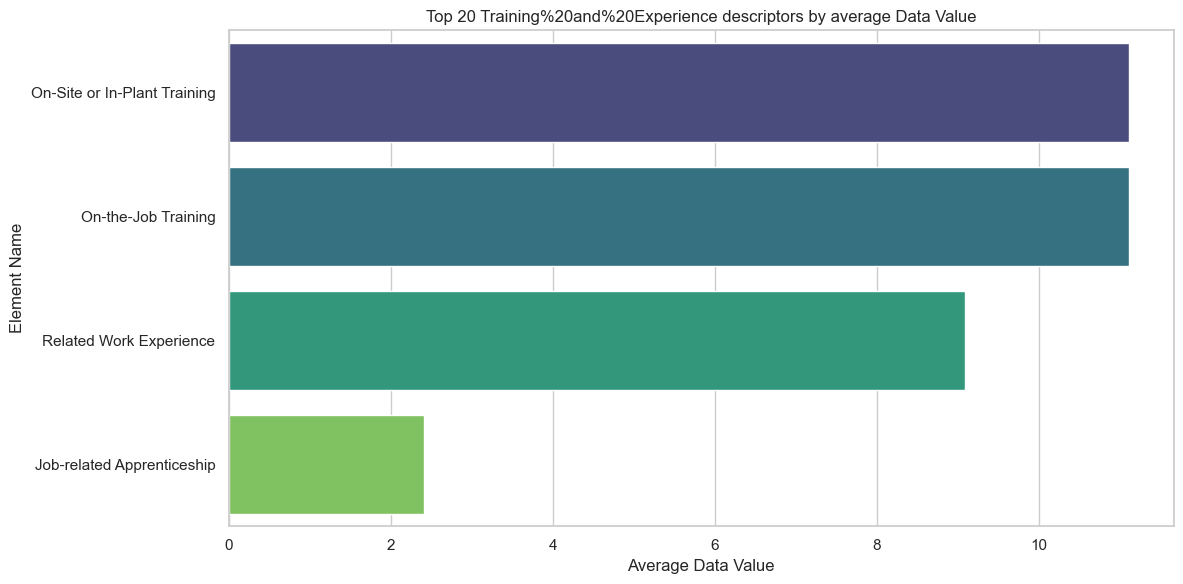


Dataset: Transferable Skills
Descriptor column: Element Name
Importance column: Data Value


/var/folders/y4/lh8fczc90wl0bvv1dm11w49m0000gn/T/ipykernel_41174/617386588.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


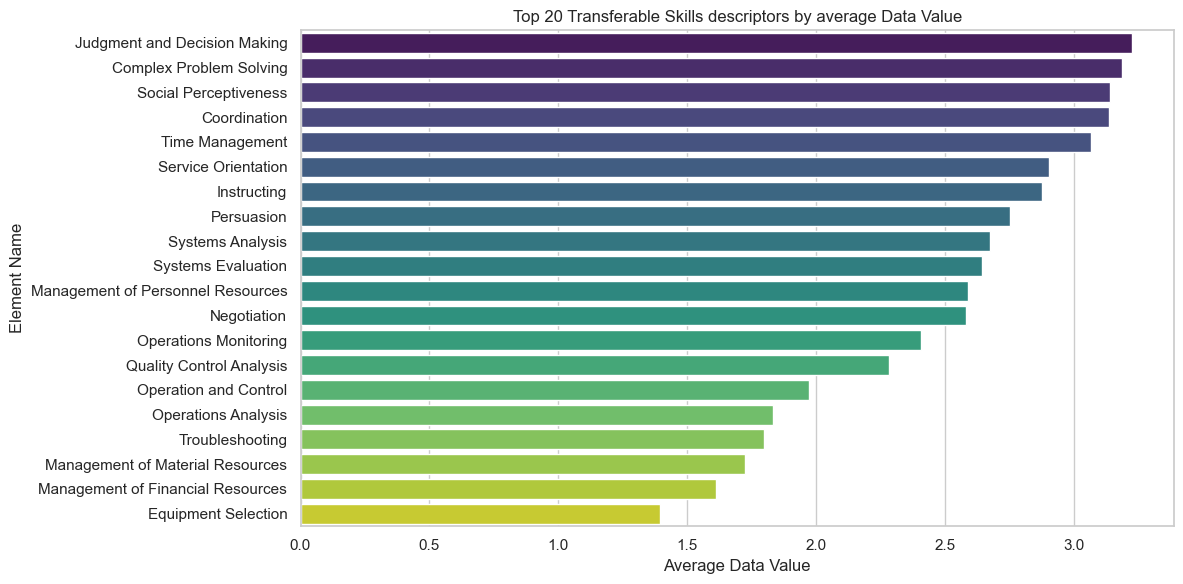

No numeric importance column detected in Transferable%20Skills%20to%20Work%20Activities.
No numeric importance column detected in Transferable%20Skills%20to%20Work%20Context.

Dataset: Transferable%20Skills
Descriptor column: Element Name
Importance column: Data Value


/var/folders/y4/lh8fczc90wl0bvv1dm11w49m0000gn/T/ipykernel_41174/617386588.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


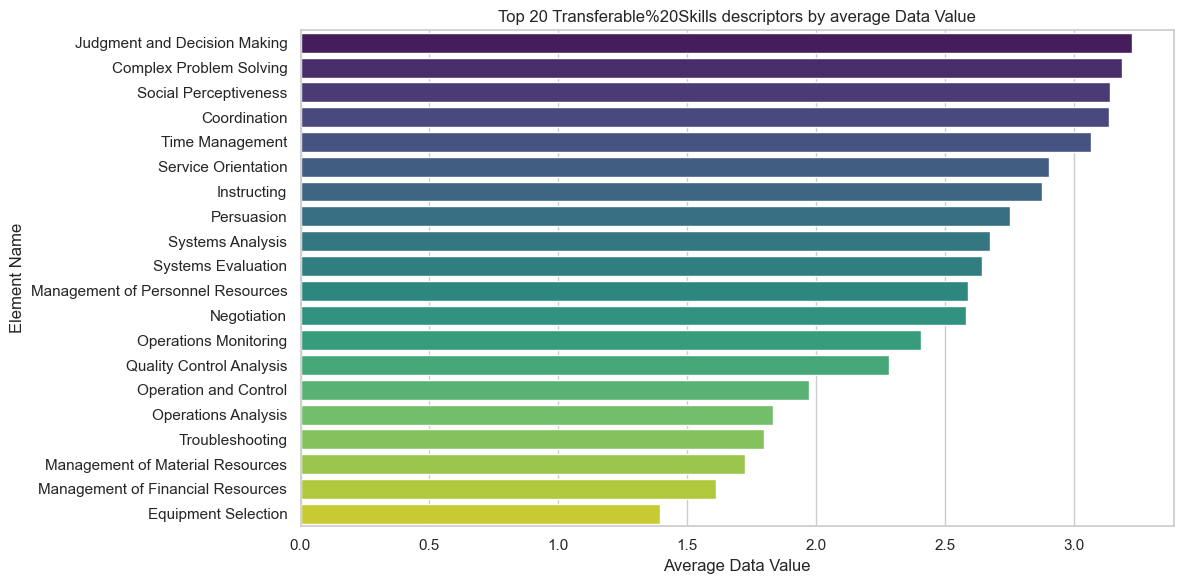

No numeric importance column detected in Transferable_Skills_Competencies.

Dataset: Work Activities
Descriptor column: Element Name
Importance column: Data Value


/var/folders/y4/lh8fczc90wl0bvv1dm11w49m0000gn/T/ipykernel_41174/617386588.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


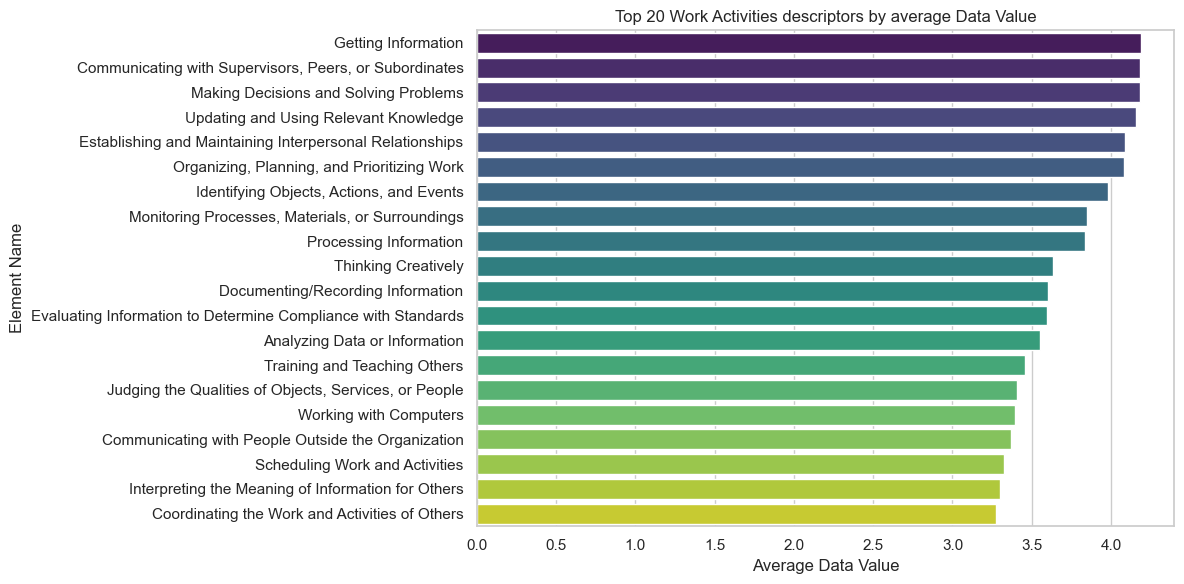


Dataset: Work Styles
Descriptor column: Element Name
Importance column: Data Value


/var/folders/y4/lh8fczc90wl0bvv1dm11w49m0000gn/T/ipykernel_41174/617386588.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


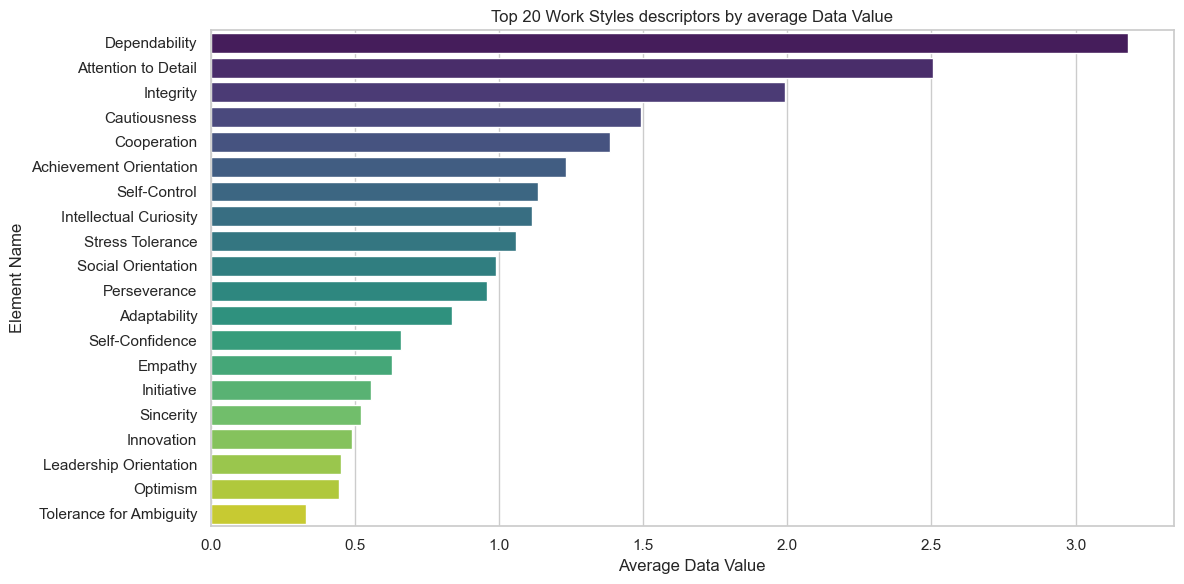

No numeric importance column detected in Work_Activities_Competencies.


In [ ]:
import glob

files = sorted(Path('datasets/onet').glob('*.xlsx'))
other_files = [f for f in files if f.name not in {'Abilities.xlsx', 'Education.xlsx', 'Essential Skills.xlsx', 'Software Skills.xlsx'}]

if other_files:
    print('Found additional dataset files:')
    for f in other_files:
        print(' -', f.name)

    for file_path in other_files:
        df = pd.read_excel(file_path)
        plot_importance(df, file_path.stem)
else:
    print('No additional O*NET .xlsx files found for this section.')